In [20]:
import dill
import json
from rich import print
from matplotlib import pyplot as plt
from matplotlib import rcParams as rc
from ipywidgets import widgets
from ipywidgets import VBox, interactive_output
import numpy as np
import pandas as pd
from simpeg.electromagnetics.utils.em1d_utils import get_vertical_discretization
from simpeg.electromagnetics.utils.em1d_utils import Stitched1DModel
from types import SimpleNamespace

rc["font.family"] = "Times New Roman"
rc["font.size"] = 14
rc["figure.figsize"] = (6, 4)
rc["axes.grid"] = True

In [21]:
istart_channel:int = 3
iend_channel:int = 25
# Load the configuration file
conf = json.load(open("../../atem/data/atem.json"))
times = np.asarray(conf['channels'])[istart_channel:iend_channel] * 1e-6
n_turns = conf['n_turns']

In [22]:
area:str = "NE"
path:str = f"../../atem/data/11-024_Alberta_{area}.csv"
dheader:list = [f"zoff30[{i}]" for i in range(istart_channel,iend_channel)]
picker:list = ["Line", "bheight", "TranPeak", "x_wgs84", "y_wgs84", "flight", 'pwrline','dtm'] + dheader # power line monitor

In [23]:
raws = pd.read_csv(path)[picker]
xy = raws[["x_wgs84", "y_wgs84"]].to_numpy()
normalizer = (-1e-9)/ (raws["TranPeak"].values * n_turns).reshape(-1, 1)
raws[[f"zoff30[{i}]" for i in range(istart_channel, iend_channel)]] = raws[[f"zoff30[{i}]" for i in range(istart_channel, iend_channel)]] * normalizer

In [24]:
line_no = list(raws["Line"].unique())

In [25]:
nan_list = raws[raws["y_wgs84"].isna()]["Line"].unique()
print(nan_list)
counts = []
for line_n in nan_list:
    count = raws[raws["Line"] == line_n]["y_wgs84"].isna().sum()
    counts.append(count)
print(counts)

<StringArray>
['L10151', 'L10460', 'L10660', 'L10700']
Length: 4, dtype: str

[65, 1, 280, 1045]

Text(0.5, 1.0, 'Line having NaN values in y_wgs84')

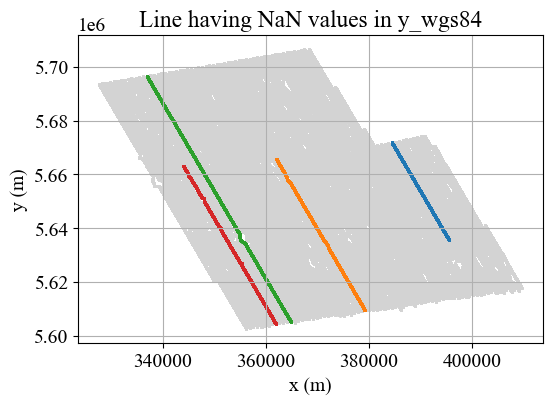

In [26]:
plt.scatter(xy[:, 0], xy[:, 1], s=1, c='lightgray', label="All data")
i=0
for line_n in nan_list:
    test_x = raws[raws["Line"] == line_n]["x_wgs84"]
    test_y = raws[raws["Line"] == line_n]["y_wgs84"]
    plt.scatter(test_x, test_y, s=1, c=f"C{i}", label=line_n)
    i += 1
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Line having NaN values in y_wgs84")

In [27]:
raws.dropna(subset=["y_wgs84"], inplace=True) # Remove rows with NaN values in y_wgs84
raws.fillna(1e-20, inplace=True) # Replace remaining NaN values with a small number (1e-20) to avoid issues in calculations

,Line,bheight,TranPeak,x_wgs84,y_wgs84,flight,pwrline,dtm,zoff30[3],zoff30[4],...,zoff30[15],zoff30[16],zoff30[17],zoff30[18],zoff30[19],zoff30[20],zoff30[21],zoff30[22],zoff30[23],zoff30[24]
0,L10040,51.911278,458.3756,402493.257158,5.641032e+06,503,-8,794.946128,-9.643729e-10,-7.876096e-10,...,-1.134681e-10,-9.594972e-11,-8.056059e-11,-6.506674e-11,-5.380087e-11,-4.421049e-11,-3.535748e-11,-2.819742e-11,-2.205398e-11,-1.766893e-11
1,L10040,51.951504,458.3796,402494.415637,5.641030e+06,503,-8,794.909939,-9.625347e-10,-7.862180e-10,...,-1.133346e-10,-9.575968e-11,-8.034887e-11,-6.487698e-11,-5.361121e-11,-4.407762e-11,-3.520288e-11,-2.806906e-11,-2.192132e-11,-1.753630e-11
2,L10040,51.990196,458.3752,402495.574117,5.641028e+06,503,-8,794.875007,-9.607055e-10,-7.848321e-10,...,-1.132120e-10,-9.559327e-11,-8.013431e-11,-6.470591e-11,-5.344875e-11,-4.394562e-11,-3.507516e-11,-2.795435e-11,-2.177165e-11,-1.737787e-11
3,L10040,52.028530,458.3842,402496.732597,5.641026e+06,503,-8,794.840569,-9.588767e-10,-7.834475e-10,...,-1.131146e-10,-9.543072e-11,-7.991971e-11,-6.454396e-11,-5.331321e-11,-4.384081e-11,-3.497925e-11,-2.784985e-11,-2.162800e-11,-1.722122e-11
4,L10040,52.065350,458.3826,402497.891079,5.641024e+06,503,-8,794.807567,-9.570899e-10,-7.820963e-10,...,-1.130134e-10,-9.526399e-11,-7.971802e-11,-6.438149e-11,-5.318124e-11,-4.374807e-11,-3.491266e-11,-2.776143e-11,-2.149592e-11,-1.705858e-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2468249,L10795,47.950359,460.7822,350092.607768,5.620167e+06,537,-14,976.952278,-5.277656e-10,-4.259794e-10,...,-5.095371e-11,-4.073690e-11,-3.314252e-11,-2.727702e-11,-2.102542e-11,-1.627180e-11,-1.283453e-11,-1.178583e-11,-1.098103e-11,-9.639738e-12
2468250,L10795,48.262875,460.7836,350094.300742,5.620164e+06,537,-14,976.924965,-5.240232e-10,-4.230274e-10,...,-5.057818e-11,-4.056675e-11,-3.306444e-11,-2.703948e-11,-2.084331e-11,-1.615130e-11,-1.266985e-11,-1.156742e-11,-1.080611e-11,-9.521045e-12
2468251,L10795,48.575470,460.7808,350095.995313,5.620162e+06,537,-14,976.898144,-5.201460e-10,-4.199702e-10,...,-5.014192e-11,-4.030966e-11,-3.291694e-11,-2.677578e-11,-2.065676e-11,-1.597851e-11,-1.246160e-11,-1.133130e-11,-1.056570e-11,-9.328209e-12
2468252,L10795,48.888226,460.7936,350097.689886,5.620159e+06,537,-14,976.872093,-5.162822e-10,-4.169470e-10,...,-4.974798e-11,-4.008213e-11,-3.278211e-11,-2.654657e-11,-2.050933e-11,-1.579721e-11,-1.227103e-11,-1.110839e-11,-1.026474e-11,-9.100929e-12


In [28]:
dx = 50.
values = []
values_std = []
soundings = []
istart = 0
iend = len(line_no)

for i_line, line in enumerate(line_no[istart:iend]):
    df_line = raws[raws['Line']==line]

    # Calculate distance along the "Line"
    xy = df_line[["x_wgs84", "y_wgs84"]].to_numpy()
    distance = np.sqrt(((xy-xy[0,:])**2).sum(axis=1))
    # print(f"Number of NaN values in distance: {np.isnan(distance).sum()}")
    max_distance = distance.max()

    # Determine the no. of soundings per bin.
    if max_distance % dx ==0:
        n_sounding = int(max_distance / dx)
    else:
        n_sounding = int(np.round(max_distance / dx) + 1)

    # Create bins and assign each sounding to a bin
    bins = np.arange(n_sounding) * dx
    df_line.insert(0, 'distance', distance)
    # Bin distances
    df_line['bin'] = pd.cut(df_line['distance'], bins=bins)
    # Compute statistics per bin
    binned = (
        df_line.groupby('bin', observed=False)
            [['distance'] + picker[1:]]
            .mean()
    )
    binned.insert(0, 'Line', line)
    binned_std = (
        df_line.groupby('bin', observed=False)
            [['bheight'] + dheader]
            .std()
    )
    values.append(binned.values)
    values_std.append(binned_std.values)
    soundings.append(n_sounding)

df_data_binned = pd.DataFrame(data=np.vstack(values), columns=['Line', 'distance'] + picker[1:])
df_data_std_binned = pd.DataFrame(data=np.vstack(values_std), columns=['bheight'] + dheader)

# Store distance information for each line
distance_by_line = {}
for i_line, line in enumerate(line_no):
    line_start_idx = sum(soundings[:i_line])
    line_end_idx = line_start_idx + soundings[i_line]
    distance_by_line[line] = df_data_binned.iloc[line_start_idx:line_end_idx]['distance'].values

In [29]:
n_time = len(times)
dobs = df_data_binned[dheader].values.flatten() # Binned Data

In [30]:
name:str = "../data/inv_results_atem_full.pik"
outDict:dict = dill.load(open(name, "rb"))
print(outDict.keys())

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])

In [31]:
print(outDict[1])

{
    'iter': 1,
    'beta': 80275.31415254179,
    'phi_d': 373871778.6128821,
    'phi_m': 888.1314999063807,
    'f': 1504621616.6608787,
    'm': array([-2.47541394, -2.47351701, -2.46993437, ..., -2.43451266,
       -2.43341609, -2.43281516]),
    'dpred': array([-1.31944225e-09, -1.06160570e-09, -8.22904296e-10, ...,
       -3.64451994e-11, -3.01170596e-11, -2.47735672e-11]),
    'SparseSmallness.irls_threshold': 1e-08,
    'SparseSmallness.norm': 1,
    'r LaterallyConstrainedSmoothness.irls_threshold': 1e-08,
    'r LaterallyConstrainedSmoothness.norm': 1,
    'z LaterallyConstrainedSmoothness.irls_threshold': 1e-08,
    'z LaterallyConstrainedSmoothness.norm': 1
}

In [32]:
iterations = len(outDict.keys())
print(f"{iterations=}")

iterations=20

In [33]:
def plot_iteration_line(i_iteration, line_name):
    """
    Plot all predicted and observed data for a specific iteration and line.
    X-axis: distance along the line
    Y-axis: response for each time channel
    
    Parameters:
    - i_iteration: Iteration number (1 to iterations)
    - line_name: Line identifier string
    """
    i_line_num = line_no.index(line_name)
    
    # Get the global sounding indices for this line
    line_start_idx = sum(soundings[:i_line_num])
    n_soundings_in_line = soundings[i_line_num]
    
    DPRED = outDict[i_iteration]['dpred'].reshape((-1, n_time))
    DOBS = dobs.reshape((-1, n_time))
    
    # Get distances for this line
    distances = distance_by_line[line_name]
    
    # Sort by distance to handle non-monotonic ordering
    sort_idx = np.argsort(distances)
    distances_sorted = distances[sort_idx]
    
    plt.figure(figsize=(12, 6))
    
    # Plot each time channel
    for i_time in range(n_time):
        dpred_line = -DPRED[line_start_idx:line_start_idx + n_soundings_in_line, i_time]
        dobs_line = -DOBS[line_start_idx:line_start_idx + n_soundings_in_line, i_time]
        
        # Sort by distance
        dpred_sorted = dpred_line[sort_idx]
        dobs_sorted = dobs_line[sort_idx]
        
        plt.plot(distances_sorted, dpred_sorted, '-', linewidth=1.5, alpha=0.7, label=f'T{i_time}')
        plt.plot(distances_sorted, dobs_sorted, 'k--', linewidth=1, alpha=0.5)
    
    plt.yscale('log')
    plt.xlabel('Distance along line (m)')
    plt.ylabel('|dB/dt| (V/A/m²)')
    plt.legend(ncol=2, fontsize=8)
    plt.grid(False)
    plt.title(f"Iteration {i_iteration}, Line {line_name}")
    plt.tight_layout()
    plt.show()


iter_slider = widgets.IntSlider(min=1, max=iterations, value=1, continuous_update=False, description='Iteration:')
line_dropdown = widgets.Dropdown(options=line_no, value=line_no[0], description='Line:')

output = interactive_output(plot_iteration_line, 
                           {'i_iteration': iter_slider, 
                            'line_name': line_dropdown})

VBox([iter_slider, line_dropdown, output])

In [34]:

topography = df_data_binned[['x_wgs84','y_wgs84', 'dtm']].values
source_heights = df_data_binned['bheight'].values
thickness = get_vertical_discretization(21, 2, 1.17)

>> Depth from the surface to the base of the bottom layer is 306.3m


In [35]:

input_data_dict = {
    "topography": topography.astype(float),
    "source_heights": source_heights.astype(float),
    "thickness": thickness,
    "times":times,    
}
inp = SimpleNamespace(**input_data_dict)

In [36]:
m = outDict[1]['m']

In [ ]:

line = np.array([int(str(val).strip('L').strip('T')) for val in df_data_binned['Line'].values])
unique_line_values = np.unique(line)
line_name_values = [str(val) for val in line_no]

n_sounding = len(line)

# Build a Stitched1DModel for a given iteration.
def make_iteration_model(iteration):
    m_iter = np.asarray(outDict[iteration]['m'])
    return Stitched1DModel(
        topography=inp.topography,
        physical_property=1. / np.exp(m_iter),
        line=line,
        time_stamp=np.arange(n_sounding),
        thicknesses=thickness,
    )

# Plot the resistivity section for one line and iteration.
def plot_iteration_line_model(i_iteration, line_name):
    selected_line_value = int(str(line_name).strip('L').strip('T'))
    selected_line_index = np.where(unique_line_values == selected_line_value)[0][0]

    model = make_iteration_model(i_iteration)

    fig, ax = plt.subplots(1, 1, figsize=(16, 5))
    out, ax = model.plot_section(
        x_axis='distance',
        aspect='auto',
        dx=dx,
        alpha=1,
        cmap='turbo',
        clim=(8, 60),
        ax=ax,
        show_colorbar=False,
        i_line=selected_line_index,
    )

    cb = plt.colorbar(out, ax=ax, orientation='horizontal', fraction=0.04)
    cb.set_label("Resistivity (ohm-m)")
    ax.set_title(f"Iteration {i_iteration} — Line {line_name}")
    plt.tight_layout()
    plt.show()

line_dropdown = widgets.Dropdown(
    options=line_name_values,
    value=line_name_values[0],
    description='Line:',
)
iter_slider = widgets.IntSlider(
    min=1,
    max=iterations,
    step=1,
    value=1,
    description='Iteration:',
    continuous_update=False,
)

output = interactive_output(
    plot_iteration_line_model,
    {'i_iteration': iter_slider, 'line_name': line_dropdown},
)

VBox([iter_slider, line_dropdown, output])

In [ ]:
from matplotlib.colors import LogNorm

DOBS = dobs.reshape((-1, n_time))
dobs_line_name_values = [str(val) for val in line_no]

def plot_dobs_time_channel_line(time_channel, line_name):
    i_time = time_channel - istart_channel
    i_line_num = line_no.index(line_name)

    line_start_idx = sum(soundings[:i_line_num])
    n_soundings_in_line = soundings[i_line_num]

    dobs_line = -DOBS[line_start_idx:line_start_idx + n_soundings_in_line, i_time].astype(float)
    xy_line = df_data_binned.iloc[line_start_idx:line_start_idx + n_soundings_in_line][['x_wgs84', 'y_wgs84']].to_numpy(dtype=float)
    xy_all = df_data_binned[['x_wgs84', 'y_wgs84']].to_numpy(dtype=float)

    is_valid = np.isfinite(xy_line[:, 0]) & np.isfinite(xy_line[:, 1]) & np.isfinite(dobs_line) & (dobs_line > 0)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.scatter(xy_all[:, 0], xy_all[:, 1], s=1, c='lightgray', label='All data')

    out = ax.scatter(
        xy_line[is_valid, 0],
        xy_line[is_valid, 1],
        s=12,
        c=dobs_line[is_valid],
        cmap='turbo',
        norm=LogNorm(),
        label=line_name,
    )

    cb = plt.colorbar(out, ax=ax, fraction=0.04)
    cb.set_label('|dB/dt| (V/A/m^2)')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_title(f"Time Channel {time_channel} ({times[i_time]:.2e} s) - Line {line_name}")
    plt.tight_layout()
    plt.show()

dobs_line_dropdown = widgets.Dropdown(
    options=dobs_line_name_values,
    value=dobs_line_name_values[0],
    description='Line:',
)
time_channel_slider = widgets.IntSlider(
    min=istart_channel,
    max=iend_channel - 1,
    step=1,
    value=istart_channel,
    description='Time Channel:',
    continuous_update=False,
)

dobs_output = interactive_output(
    plot_dobs_time_channel_line,
    {'time_channel': time_channel_slider, 'line_name': dobs_line_dropdown},
)

VBox([time_channel_slider, dobs_line_dropdown, dobs_output])
